In [3]:
# ===============================
# 1. INSTALL LIBRARIES
# ===============================
!pip install -q monai nibabel torch torchvision tqdm matplotlib

In [4]:
# ===============================
# 2. IMPORT LIBRARIES
# ===============================

import os
import glob
import tarfile
import urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt
import nibabel as nib

from tqdm import tqdm

from monai.utils import set_determinism

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    AsDiscrete
)

from monai.data import Dataset, DataLoader, decollate_batch

from monai.networks.nets import UNet

from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [5]:
# ===============================
# 3. DEVICE SETUP
# ===============================

set_determinism(seed=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [6]:
# ===============================
# 4. CREATE OUTPUT DIRECTORIES
# ===============================

BASE_DIR = "edge_output"

MODEL_DIR = os.path.join(BASE_DIR, "models")
IMAGE_DIR = os.path.join(BASE_DIR, "predictions")
GRAPH_DIR = os.path.join(BASE_DIR, "graphs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)

print("Folders created.")

Folders created.


In [7]:
# ===============================
# 5. DOWNLOAD DATASET
# ===============================

url = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar"
filename = "Task01_BrainTumour.tar"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

if not os.path.exists("Task01_BrainTumour"):
    tar = tarfile.open(filename)
    tar.extractall()
    tar.close()

data_dir = "./Task01_BrainTumour"

print("Dataset ready")

Dataset ready


In [8]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    RandCropByPosNegLabeld,
    ToTensord
)

from monai.data import Dataset
import glob
import os

# Dataset path
images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))

data_dicts = [{"image": image, "label": label} for image, label in zip(images, labels)]

# MONAI transforms
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"])
])

# Create dataset
train_dataset = Dataset(data=data_dicts, transform=train_transforms)

print("Training dataset created:", len(train_dataset))

Training dataset created: 484


In [9]:
# ===============================
# 6. DATASET PREPARATION
# ===============================

images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))

data_dicts = [
    {"image": img, "label": lbl}
    for img, lbl in zip(images, labels)
]

train_files = data_dicts[:80]
val_files = data_dicts[80:100]

print("Train:", len(train_files))
print("Validation:", len(val_files))

Train: 80
Validation: 20


In [10]:
# ===============================
# 7. TRANSFORMS (FIXED)
# ===============================

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    ResizeWithPadOrCropd,
    ScaleIntensityRanged
)

train_transforms = Compose([
    LoadImaged(keys=["image","label"]),

    EnsureChannelFirstd(keys=["image","label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=3000,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),

    # IMPORTANT FIX
    ResizeWithPadOrCropd(
        keys=["image","label"],
        spatial_size=(128,128,128)
    ),

    EnsureTyped(keys=["image","label"])
])


val_transforms = Compose([
    LoadImaged(keys=["image","label"]),

    EnsureChannelFirstd(keys=["image","label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=3000,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),

    ResizeWithPadOrCropd(
        keys=["image","label"],
        spatial_size=(128,128,128)
    ),

    EnsureTyped(keys=["image","label"])
])

In [11]:
# ===============================
# 8. DATA LOADERS
# ===============================

train_ds = Dataset(train_files, train_transforms)
val_ds = Dataset(val_files, val_transforms)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1)

print("Dataset ready")

Dataset ready


In [12]:
# ===============================
# 9. MODEL
# ===============================

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16,32,64,128,256),
    strides=(2,2,2,2)
).to(device)

In [13]:
# ===============================
# 10. LOSS + OPTIMIZER
# ===============================

loss_function = DiceLoss(to_onehot_y=True, softmax=True)

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

In [14]:
# ===============================
# 11. METRICS
# ===============================

dice_metric = DiceMetric(include_background=True, reduction="mean")

post_pred = Compose([AsDiscrete(argmax=True, to_onehot=4)])

post_label = Compose([AsDiscrete(to_onehot=4)])

In [15]:
# ===============================
# 12. TRAIN FUNCTION
# ===============================

def train_epoch(model, loader, optimizer, loss_function):

    model.train()

    epoch_loss = 0

    for batch_data in loader:

        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss = epoch_loss / len(loader)

    return epoch_loss

In [16]:
# ===============================
# 13. VALIDATION FUNCTION
# ===============================

def validate_epoch(model, loader):

    model.eval()

    dice_metric.reset()

    with torch.no_grad():

        for val_data in loader:

            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)

            val_outputs = sliding_window_inference(
                val_inputs,
                (96,96,96),
                1,
                model
            )

            val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
            val_labels = [post_label(i) for i in decollate_batch(val_labels)]

            dice_metric(y_pred=val_outputs, y=val_labels)

    metric = dice_metric.aggregate().item()

    dice_metric.reset()

    return metric

In [17]:
# ===============================
# 14. TRAINING LOOP
# ===============================

max_epochs = 150

best_metric = -1

train_losses = []
val_dice_scores = []

for epoch in range(max_epochs):

    print("Epoch:", epoch+1)

    train_loss = train_epoch(model, train_loader, optimizer, loss_function)

    val_metric = validate_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_dice_scores.append(val_metric)

    print("Train Loss:", train_loss)
    print("Validation Dice:", val_metric)

    if val_metric > best_metric:

        best_metric = val_metric

        torch.save(model.state_dict(), os.path.join(MODEL_DIR,"best_model.pth"))

        print("Best Model Saved")

Epoch: 1
Train Loss: 0.8624737277626991
Validation Dice: 0.24836373329162598
Best Model Saved
Epoch: 2
Train Loss: 0.8206148616969585
Validation Dice: 0.34825268387794495
Best Model Saved
Epoch: 3
Train Loss: 0.780261118710041
Validation Dice: 0.41143321990966797
Best Model Saved
Epoch: 4
Train Loss: 0.744828249514103
Validation Dice: 0.4576748013496399
Best Model Saved
Epoch: 5
Train Loss: 0.7157982058823109
Validation Dice: 0.5029430985450745
Best Model Saved
Epoch: 6
Train Loss: 0.6893065147101879
Validation Dice: 0.533416211605072
Best Model Saved
Epoch: 7
Train Loss: 0.6656010746955872
Validation Dice: 0.5468486547470093
Best Model Saved
Epoch: 8
Train Loss: 0.6419698305428028
Validation Dice: 0.547612726688385
Best Model Saved
Epoch: 9
Train Loss: 0.6182628981769085
Validation Dice: 0.5573869943618774
Best Model Saved
Epoch: 10
Train Loss: 0.5967823259532452
Validation Dice: 0.5647417306900024
Best Model Saved
Epoch: 11
Train Loss: 0.5746135596185923
Validation Dice: 0.5845062136

In [18]:
# ===============================
# 15. SAVE MODEL
# ===============================

torch.save(model.state_dict(), os.path.join(MODEL_DIR,"final_model.pth"))

print("Model saved")

Model saved


In [19]:
# ===============================
# 16. QUANTIZE MODEL
# ===============================

quantized_model = torch.quantization.quantize_dynamic(
    model.cpu(),
    {torch.nn.Linear},
    dtype=torch.qint8
)

torch.save(
    quantized_model.state_dict(),
    os.path.join(MODEL_DIR,"quantized_model.pth")
)

print("Quantized model saved")

Quantized model saved


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = model.to(device)
model.eval()

with torch.no_grad():
    for i, val_data in enumerate(val_loader):

        val_inputs = val_data["image"].to(device)

        val_outputs = sliding_window_inference(
            val_inputs,
            (96, 96, 96),
            1,
            model
        )

        pred = torch.argmax(val_outputs, dim=1)
        pred_np = pred.cpu().numpy()[0]

        save_path = os.path.join(IMAGE_DIR, f"prediction_{i}.nii.gz")
        nib.save(nib.Nifti1Image(pred_np.astype(np.float32), np.eye(4)), save_path)

print("Predictions saved")

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

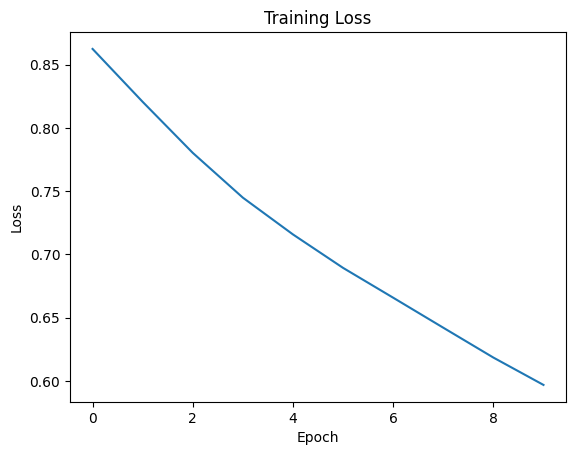

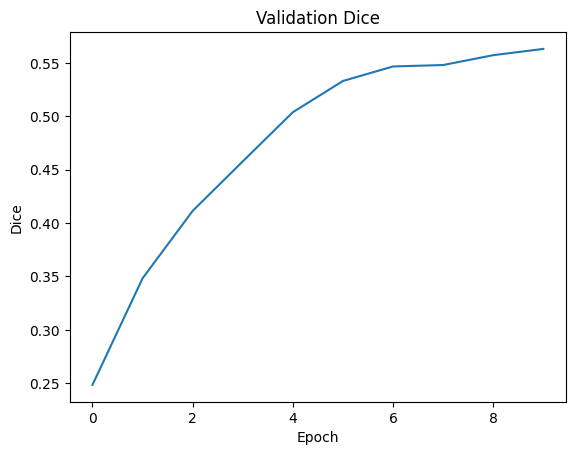

Graphs saved


In [ ]:
# ===============================
# 18. TRAINING GRAPHS
# ===============================

plt.figure()

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.savefig(os.path.join(GRAPH_DIR,"training_loss.png"))

plt.show()


plt.figure()

plt.plot(val_dice_scores)

plt.title("Validation Dice")

plt.xlabel("Epoch")

plt.ylabel("Dice")

plt.savefig(os.path.join(GRAPH_DIR,"validation_dice.png"))

plt.show()

print("Graphs saved")

In [ ]:
# ===============================
# 17. SAVE PREDICTIONS AS JPG
# ===============================

import cv2
import os

model.eval()

with torch.no_grad():

    for i, val_data in enumerate(val_loader):

        val_inputs = val_data["image"].to(device)

        val_outputs = sliding_window_inference(
            val_inputs,
            (96,96,96),
            1,
            model
        )

        pred = torch.argmax(val_outputs, dim=1)

        pred_np = pred.cpu().numpy()[0]   # shape: (H, W, D)

        # create folder for each volume
        volume_dir = os.path.join(IMAGE_DIR, f"prediction_{i}")
        os.makedirs(volume_dir, exist_ok=True)

        depth = pred_np.shape[2]

        for slice_id in range(depth):

            slice_img = pred_np[:, :, slice_id]

            # normalize to 0–255
            slice_img = (slice_img / slice_img.max()) * 255
            slice_img = slice_img.astype("uint8")

            save_path = os.path.join(volume_dir, f"slice_{slice_id}.jpg")

            cv2.imwrite(save_path, slice_img)

print("Predictions saved as JPG slices.")

/tmp/ipykernel_948/4186162979.py:38: RuntimeWarning: invalid value encountered in divide
  slice_img = (slice_img / slice_img.max()) * 255
/tmp/ipykernel_948/4186162979.py:39: RuntimeWarning: invalid value encountered in cast
  slice_img = slice_img.astype("uint8")


Predictions saved as JPG slices.


Best slice found at: /content/edge_output/predictions/prediction_12/slice_60.jpg


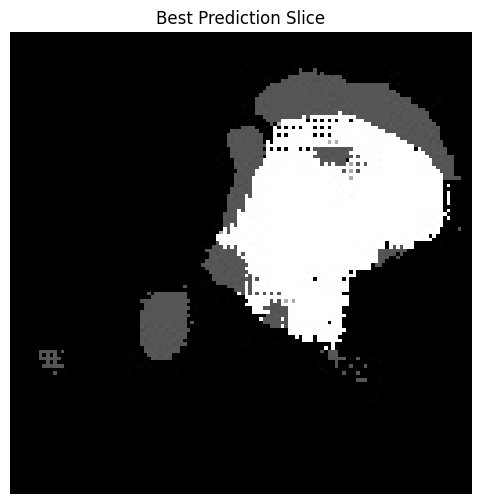

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

root_folder = "/content/edge_output/predictions"   # change if predictions are inside another folder

best_slice_path = None
best_score = 0
best_img = None

# scan all folders
for folder, subfolders, files in os.walk(root_folder):

    for file in files:

        if file.endswith(".jpg") and "slice_" in file:

            path = os.path.join(folder, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # score = number of non-black pixels
            score = np.count_nonzero(img)

            if score > best_score:
                best_score = score
                best_slice_path = path
                best_img = img

print("Best slice found at:", best_slice_path)

plt.figure(figsize=(6,6))
plt.imshow(best_img, cmap="gray")
plt.title("Best Prediction Slice")
plt.axis("off")
plt.show()

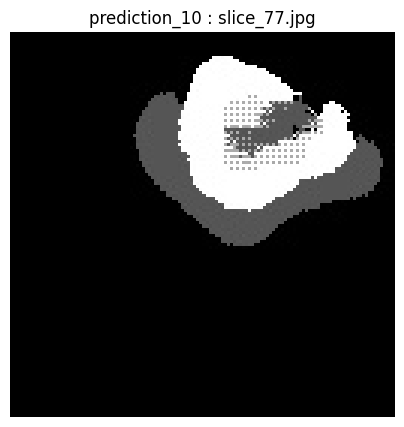

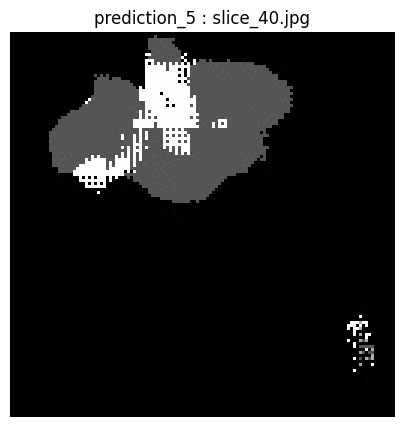

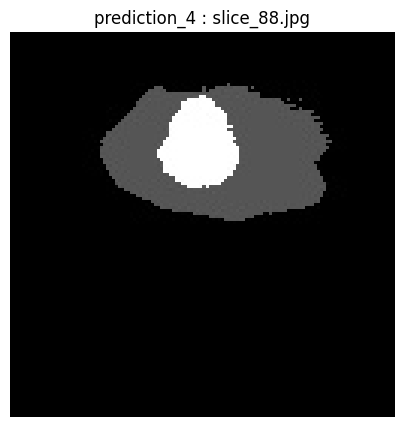

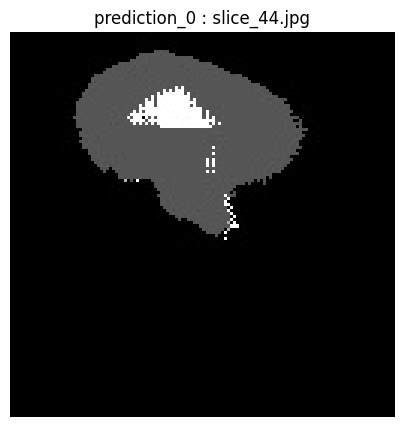

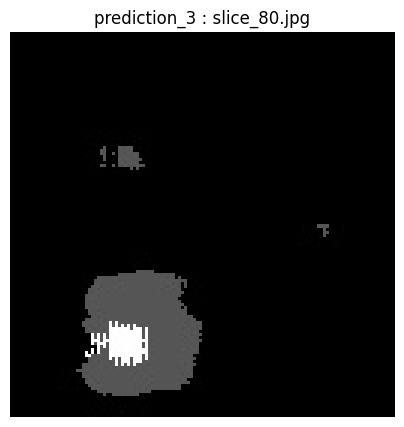

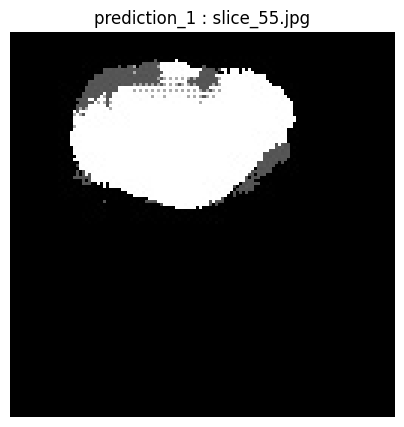

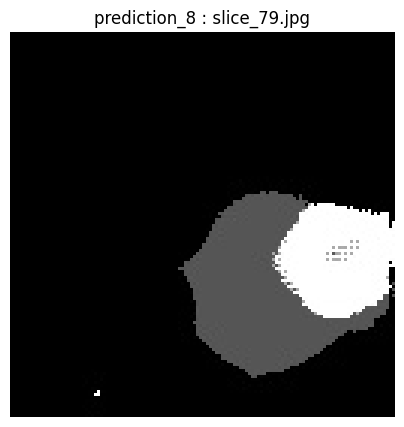

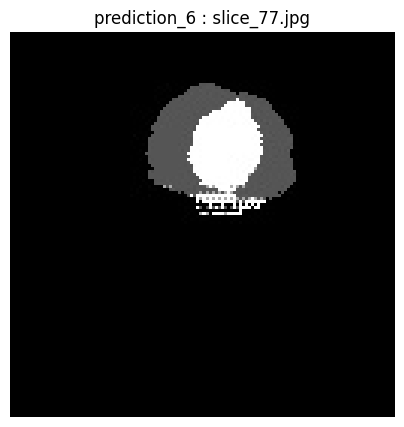

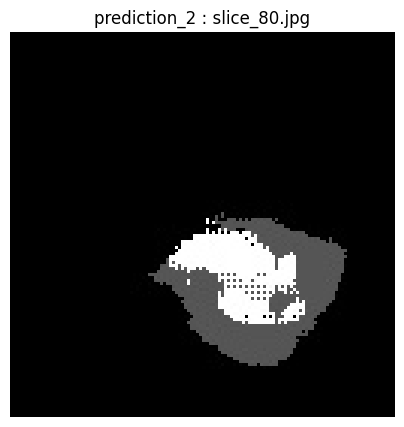

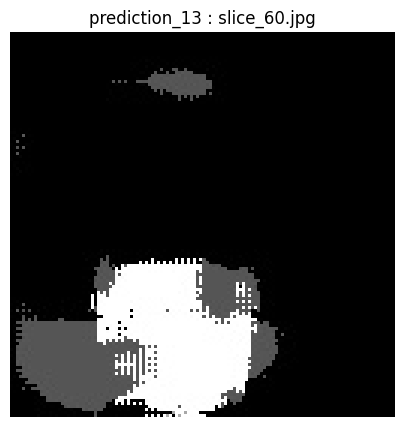

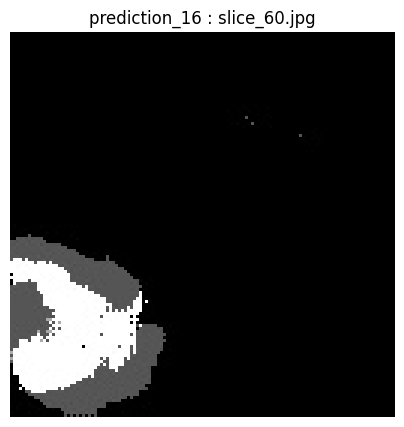

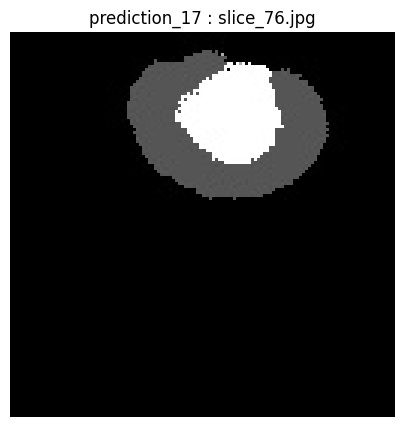

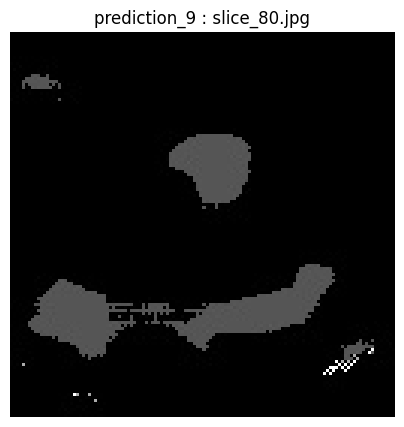

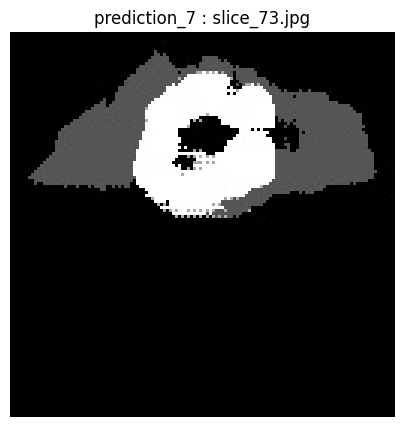

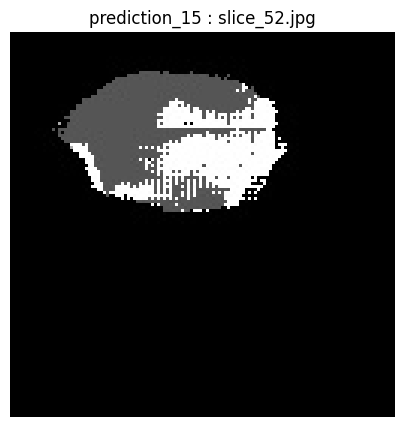

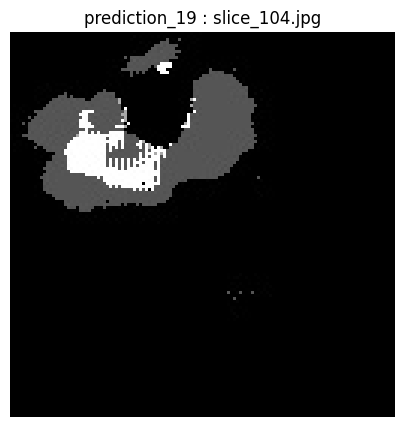

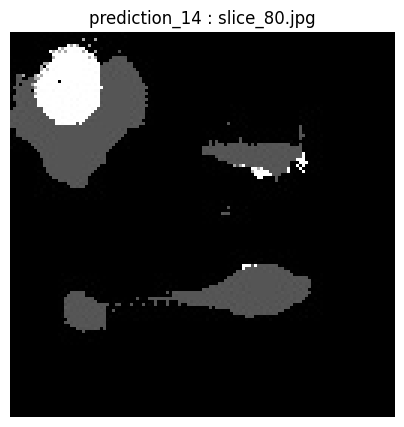

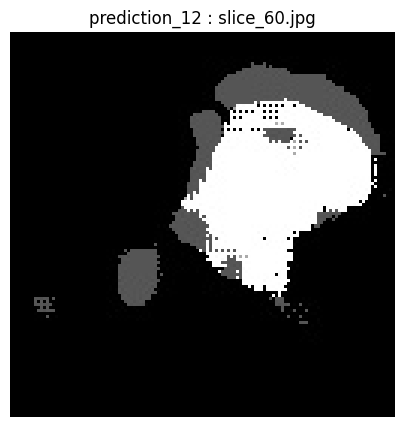

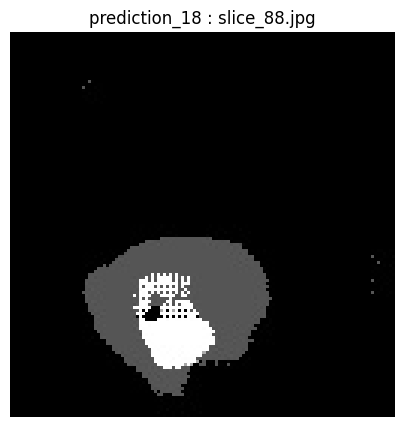

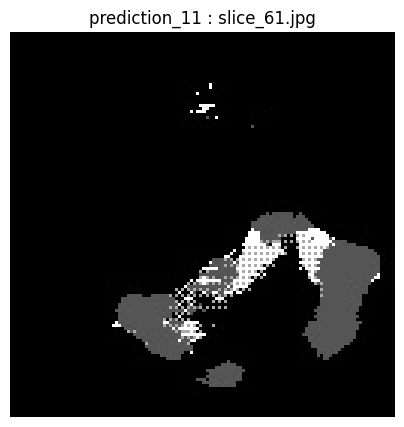

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

root_dir = "/content/edge_output/predictions"   # root directory containing prediction folders

for folder in os.listdir(root_dir):

    folder_path = os.path.join(root_dir, folder)

    if os.path.isdir(folder_path):

        best_score = 0
        best_img = None
        best_name = None

        for file in os.listdir(folder_path):

            if file.endswith(".jpg") and "slice_" in file:

                path = os.path.join(folder_path, file)
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    continue

                score = np.count_nonzero(img)

                if score > best_score:
                    best_score = score
                    best_img = img
                    best_name = file

        if best_img is not None:

            plt.figure(figsize=(5,5))
            plt.imshow(best_img, cmap="gray")
            plt.title(f"{folder} : {best_name}")
            plt.axis("off")
            plt.show()